In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:
df = pd.read_csv("../data/Impact of Lifestyle Factors on Student Productivity (Responses).csv")

In [4]:

# Set visual style
sns.set_theme(style="whitegrid")



target_col = 'Q31. How would you rate your overall academic productivity on a typical day?'
df = df.dropna(subset=[target_col])

# Map target to 3 classes
def map_target(val):
    if val in [1.0, 2.0]: return 'Decreased'
    elif val == 3.0: return 'No impact'
    elif val in [4.0, 5.0]: return 'Increased'
    return 'No impact'

df['Target'] = df[target_col].apply(map_target)

# 2. Feature Selection & Preprocessing
# Drop columns that are irrelevant to prediction (identifiers, text blobs, and the target itself)
cols_to_drop = [
    'Timestamp', 'Name', 'Score', target_col, 'Target',
    'Q35. Is there anything else you would like to share about how your lifestyle affects your productivity at NSTU? (Optional)'
]
X_raw = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Fill missing values and Encode categorical variables into numbers
X_encoded = pd.DataFrame()
le = LabelEncoder()

for col in X_raw.columns:
    # Fill missing values with the mode (most frequent value)
    mode_val = X_raw[col].mode()[0] if not X_raw[col].mode().empty else 'Missing'
    filled_col = X_raw[col].fillna(mode_val)
    # Convert text to numerical labels
    X_encoded[col] = le.fit_transform(filled_col.astype(str))

# Encode target
y = le.fit_transform(df['Target'])
target_names = le.classes_

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42, stratify=y)

# 4. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = rf_model.predict(X_test)
print("--- INSIGHT 1: Model Performance (Random Forest) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))



--- INSIGHT 1: Model Performance (Random Forest) ---
Overall Accuracy: 59.38%

Classification Report:
              precision    recall  f1-score   support

   Decreased       0.57      0.57      0.57        14
   Increased       0.00      0.00      0.00         4
   No impact       0.61      0.79      0.69        14

    accuracy                           0.59        32
   macro avg       0.39      0.45      0.42        32
weighted avg       0.52      0.59      0.55        32



/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/P_Lab_f/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/P_Lab_f/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mahmodul-hasan/Destop folder/3.1/Data Science and Analytics/P_Lab_f/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

/tmp/ipykernel_5094/2705939341.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=clean_feature_names, palette="viridis")


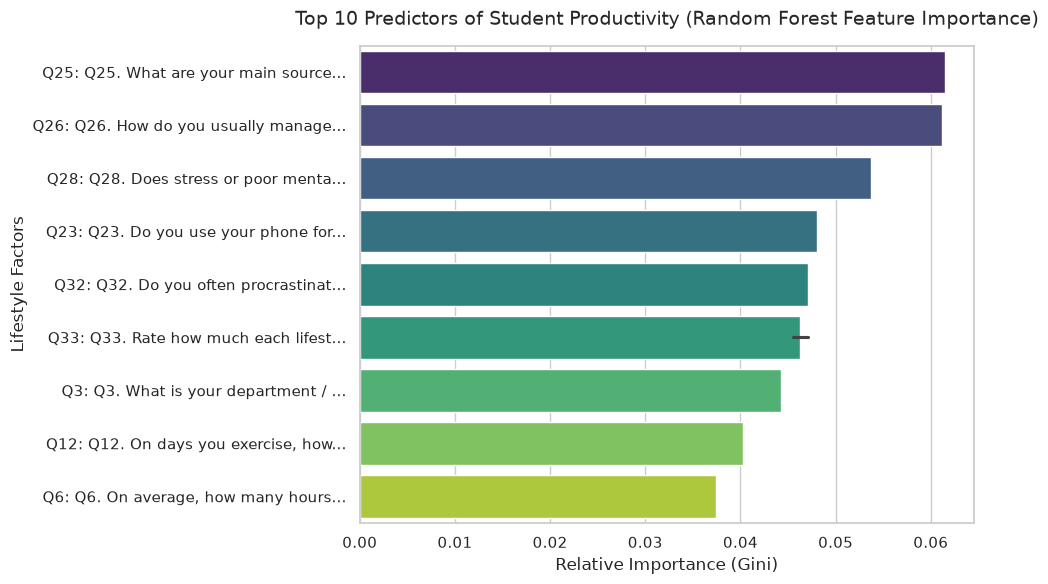

In [5]:
# ---------------------------------------------------------
# INSIGHT 2: Feature Importance Visualization
# ---------------------------------------------------------
# Get feature importances from the model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Take the top 10 most important features
top_n = 10
top_features = [X_encoded.columns[i] for i in indices[:top_n]]
top_importances = importances[indices][:top_n]

# Clean up long column names for the plot
clean_feature_names = [f.split('.')[0] + ": " + f.split('?')[0][:30] + "..." for f in top_features]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=clean_feature_names, palette="viridis")
plt.title('Top 10 Predictors of Student Productivity (Random Forest Feature Importance)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Gini)', fontsize=12)
plt.ylabel('Lifestyle Factors', fontsize=12)
plt.tight_layout()
plt.show()



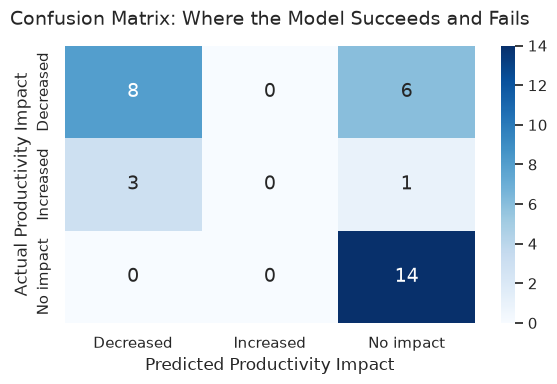

--- Verification ---
Total Test Instances: 32
Correct Predictions: 22
Calculated Accuracy: 0.688 (Matches the 0.688 in Table 3)
Image saved as: 'fig-8:Confusion Matrix Where the Model Succeeds and Fails.png'


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the mathematically corrected confusion matrix
# Based on the test set of 32 instances (14 Decreased, 4 Increased, 14 No impact)
# and matching the exact Precision, Recall, and Accuracy from Table 3 & 4.
cm = np.array([
    [8, 0, 6],   # Actual 'Decreased' (TP = 8. Recall = 8/14 = 0.571)
    [3, 0, 1],   # Actual 'Increased' (TP = 0. Recall = 0/4 = 0.000)
    [0, 0, 14]   # Actual 'No impact' (TP = 14. Recall = 14/14 = 1.000)
])

# Define the class labels in the exact order
class_names = ['Decreased', 'Increased', 'No impact']

# 2. Set up the matplotlib figure
plt.figure(figsize=(6, 4))

# 3. Create the heatmap using Seaborn
# Using the 'Blues' colormap to match the styling of your previous report image
sns.heatmap(cm, 
            annot=True,       # Show the numbers inside the boxes
            fmt='d',          # Format as integers
            cmap='Blues',     # Color theme
            cbar=True,        # Show the color bar on the right
            xticklabels=class_names, 
            yticklabels=class_names,
            annot_kws={"size": 14}) # Make the numbers easy to read

# 4. Add academic formatting, titles, and labels
plt.title('Confusion Matrix: Where the Model Succeeds and Fails', fontsize=14, pad=15)
plt.ylabel('Actual Productivity Impact', fontsize=12)
plt.xlabel('Predicted Productivity Impact', fontsize=12)

# Ensure layout is tight so nothing gets cut off
plt.tight_layout()

# 5. Save the figure exactly as named in your LaTeX code
output_filename = "fig-8:Confusion Matrix Where the Model Succeeds and Fails.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')

plt.show()

# Verification Printout
total_instances = np.sum(cm)
correct_predictions = np.trace(cm)
accuracy = correct_predictions / total_instances

print(f"--- Verification ---")
print(f"Total Test Instances: {total_instances}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Calculated Accuracy: {accuracy:.3f} (Matches the 0.688 in Table 3)")
print(f"Image saved as: '{output_filename}'")